In [3]:
import pandas as pd

prices_df = pd.read_csv("nifty20_prices.csv", 
                         index_col=0, 
                         parse_dates=True)

print(prices_df.shape)
print(prices_df.head())

(88, 18)
            RELIANCE        TCS  HDFCBANK      INFY  HINDUNILVR  ICICIBANK  \
2019-01-31  536.7049  1678.6147  488.6791  626.9873   1579.1296   351.4428   
2019-02-28  538.6512  1653.3263  488.9139  613.8972   1551.4405   336.5360   
2019-03-28       NaN  1666.8245       NaN  617.7030         NaN        NaN   
2019-03-29  596.1662        NaN  543.9421       NaN   1530.3376   384.8262   
2019-04-30  608.7408  1878.8802  543.7073  627.2801   1571.6920   393.4133   

            KOTAKBANK  BAJFINANCE  BHARTIARTL       ITC  AXISBANK     MARUTI  \
2019-01-31   249.4724    250.7748    269.5363  199.8616  719.0513  6209.3429   
2019-02-28   241.3507    258.2921    279.0137  197.9974  705.5247  6400.6432   
2019-03-28        NaN         NaN         NaN       NaN       NaN        NaN   
2019-03-29   265.8949    295.1178    292.1329  212.7316  771.9147  6250.2355   
2019-04-30   276.1067    301.8888    306.0873  216.2090  762.7643  6238.0567   

            SUNPHARMA      TITAN     WIPR

In [4]:

# Calculate month-on-month percentage returns
monthly_returns = prices_df.pct_change()

# Drop first row — it's NaN because no previous month to compare
monthly_returns = monthly_returns.dropna(how='all')

print("Returns shape:", monthly_returns.shape)
print("\nSample returns:")
print(monthly_returns.tail())

# Quick sanity check — March 2020 should show big negative numbers
# That was the Covid crash
march_2020 = monthly_returns[monthly_returns.index.strftime('%Y-%m') == '2020-03']
print("\nMarch 2020 returns (Covid crash):")
print(march_2020.T)

Returns shape: (86, 18)

Sample returns:
            RELIANCE       TCS  HDFCBANK      INFY  HINDUNILVR  ICICIBANK  \
2025-11-28  0.054053  0.026768  0.019592  0.052074   -0.015355   0.032452   
2025-12-31  0.001627  0.021053 -0.015144  0.036385   -0.046721  -0.032980   
2026-01-30 -0.110552 -0.007451 -0.062919  0.014847    0.025202   0.009048   
2026-02-27 -0.001146 -0.156366 -0.045139 -0.207565   -0.014914   0.017675   
2026-03-27 -0.033027 -0.093518 -0.147791 -0.023039   -0.112584  -0.105004   

            KOTAKBANK  BAJFINANCE  BHARTIARTL       ITC  AXISBANK    MARUTI  \
2025-11-28   0.010490   -0.004748    0.022608 -0.037716  0.038321 -0.018392   
2025-12-31   0.036135   -0.049150    0.002213 -0.003462 -0.009022  0.050972   
2026-01-30  -0.073043   -0.056859   -0.065346 -0.183743  0.080043 -0.125878   
2026-02-27   0.017892    0.070872   -0.044891 -0.026691  0.009925  0.018354   
2026-03-27  -0.118830   -0.152684   -0.020003 -0.060108 -0.129096 -0.166895   

            SUNPHARMA

In [5]:
def compute_volatility(monthly_returns):
    """
    12-1 momentum: return from 12 months ago to 1 month ago.
    Skip last month to avoid short-term reversal effect.
    """
    # rolling vol of t-12 to t-1
    vol = monthly_returns.rolling(12).std()
    return vol

# Compute volatility scores
vol_scores = compute_volatility(monthly_returns)

# Filter to same date range as returns
vol_scores = vol_scores[vol_scores.index >= "2020-01-01"]

# Drop rows where we don't have enough history yet
vol_scores = vol_scores.dropna(how='all')

print("Volatility scores shape:", vol_scores.shape)
print("\nLatest volatility scores (most recent month):")
latest = vol_scores.iloc[-1].dropna().sort_values(ascending=False)
print(latest)
print("\nTop 3 volatile stocks right now:", latest.head(3).index.tolist())
print("Bottom 3 volatile stocks right now:", latest.tail(3).index.tolist())

Volatility scores shape: (73, 18)

Latest volatility scores (most recent month):
MARUTI        0.088886
HCLTECH       0.085855
TATASTEEL     0.083586
BAJFINANCE    0.076737
TITAN         0.073103
INFY          0.072775
AXISBANK      0.071536
TCS           0.067032
WIPRO         0.064930
SUNPHARMA     0.063373
RELIANCE      0.062830
ITC           0.058590
JSWSTEEL      0.057416
HDFCBANK      0.057017
KOTAKBANK     0.056625
HINDUNILVR    0.054900
BHARTIARTL    0.054041
ICICIBANK     0.043442
Name: 2026-03-27 00:00:00, dtype: float64

Top 3 volatile stocks right now: ['MARUTI', 'HCLTECH', 'TATASTEEL']
Bottom 3 volatile stocks right now: ['HINDUNILVR', 'BHARTIARTL', 'ICICIBANK']


In [6]:
def build_portfolios(vol_scores, monthly_returns, n_quantiles=3):
    """
    Sort stocks into quantiles by volatility score each month.
    With 18 stocks, use 3 quantiles (6 stocks each) instead of 5.
    Q3 = lowest vol, Q1 = high vol.
    Long-Short = Q3 minus Q1.
    """
    portfolio_returns = {f'Q{i+1}': {} for i in range(n_quantiles)}
    portfolio_returns['LS'] = {}
    
    for date in vol_scores.index:
        # Get scores for this month
        scores = vol_scores.loc[date].dropna()
        
        # Need at least 9 stocks to make 3 groups of 3
        if len(scores) < 9:
            continue
        
        # Check if next month exists in returns
        future_dates = monthly_returns.index[monthly_returns.index > date]
        if len(future_dates) == 0:
            continue
            
        next_date = future_dates[0]
        next_returns = monthly_returns.loc[next_date]
        
        # Rank into 3 quantiles
        quantile_labels = pd.qcut(scores, n_quantiles, 
                                   labels=['Q3', 'Q2', 'Q1'])
        
        for q in ['Q1', 'Q2', 'Q3']:
            stocks = scores[quantile_labels == q].index
            # Equal weight average return of stocks in this group
            avg_ret = next_returns[stocks].mean()
            portfolio_returns[q][next_date] = avg_ret
        
        # Long Q3 (winners), Short Q1 (losers)
        portfolio_returns['LS'][next_date] = (
            portfolio_returns['Q3'][next_date] - 
            portfolio_returns['Q1'][next_date]
        )
    
    return pd.DataFrame(portfolio_returns).dropna()

# Build portfolios
portfolios = build_portfolios(vol_scores, monthly_returns)

print("Portfolio returns shape:", portfolios.shape)
print("\nSample portfolio returns:")
print(portfolios.tail())

Portfolio returns shape: (72, 4)

Sample portfolio returns:
                  Q1        Q2        Q3        LS
2025-11-28  0.012925  0.025173  0.008540 -0.004384
2025-12-31  0.014651 -0.005537  0.007156 -0.007495
2026-01-30 -0.005311 -0.047065 -0.041095 -0.035784
2026-02-27  0.020396 -0.021543 -0.059386 -0.079781
2026-03-27 -0.057667 -0.077517 -0.110428 -0.052761


In [7]:
import numpy as np
def performance_summary(returns_series, name="Strategy"):
    """
    Key performance metrics for a monthly returns series.
    """
    # Annualized return
    ann_return = returns_series.mean() * 12
    
    # Annualized volatility
    ann_vol = returns_series.std() * np.sqrt(12)
  
    
    # Sharpe Ratio — 6.5% risk free rate for India
    risk_free = 0.065
    sharpe = (ann_return - risk_free) / ann_vol
    
    # Maximum Drawdown
    cumulative = (1 + returns_series).cumprod()
    rolling_max = cumulative.expanding().max()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Win rate — how often did strategy make money
    win_rate = (returns_series > 0).mean()
    
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Annualized Return : {ann_return:.1%}")
    print(f"  Annualized Vol    : {ann_vol:.1%}")
    print(f"  Sharpe Ratio      : {sharpe:.2f}")
    print(f"  Max Drawdown      : {max_drawdown:.1%}")
    print(f"  Win Rate          : {win_rate:.1%}")
    print()
    
    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate
    }

# Run for all portfolios
results = {}
for col in ['Q1', 'Q2', 'Q3', 'LS']:
    results[col] = performance_summary(
        portfolios[col].dropna(), 
        name=f"Volatility {col}"
    )

# Summary comparison table
print("\nSUMMARY TABLE")
print(f"{'Portfolio':<12} {'Ann.Return':>10} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 42)
for col in ['Q1', 'Q2', 'Q3', 'LS']:
    r = results[col]
    print(f"{col:<12} {r['ann_return']:>10.1%} {r['sharpe']:>8.2f} {r['max_drawdown']:>8.1%}")

    # Equal weight benchmark — just average all 18 stock returns each month
benchmark = monthly_returns.mean(axis=1)

# Cumulative benchmark return
benchmark_cumulative = (1 + benchmark).cumprod()

  Volatility Q1
  Annualized Return : 28.8%
  Annualized Vol    : 19.8%
  Sharpe Ratio      : 1.13
  Max Drawdown      : -16.3%
  Win Rate          : 66.7%

  Volatility Q2
  Annualized Return : 17.0%
  Annualized Vol    : 16.2%
  Sharpe Ratio      : 0.65
  Max Drawdown      : -14.7%
  Win Rate          : 69.4%

  Volatility Q3
  Annualized Return : 21.7%
  Annualized Vol    : 17.0%
  Sharpe Ratio      : 0.89
  Max Drawdown      : -19.8%
  Win Rate          : 61.1%

  Volatility LS
  Annualized Return : -7.1%
  Annualized Vol    : 16.2%
  Sharpe Ratio      : -0.84
  Max Drawdown      : -44.3%
  Win Rate          : 52.8%


SUMMARY TABLE
Portfolio    Ann.Return   Sharpe    MaxDD
------------------------------------------
Q1                28.8%     1.13   -16.3%
Q2                17.0%     0.65   -14.7%
Q3                21.7%     0.89   -19.8%
LS                -7.1%    -0.84   -44.3%


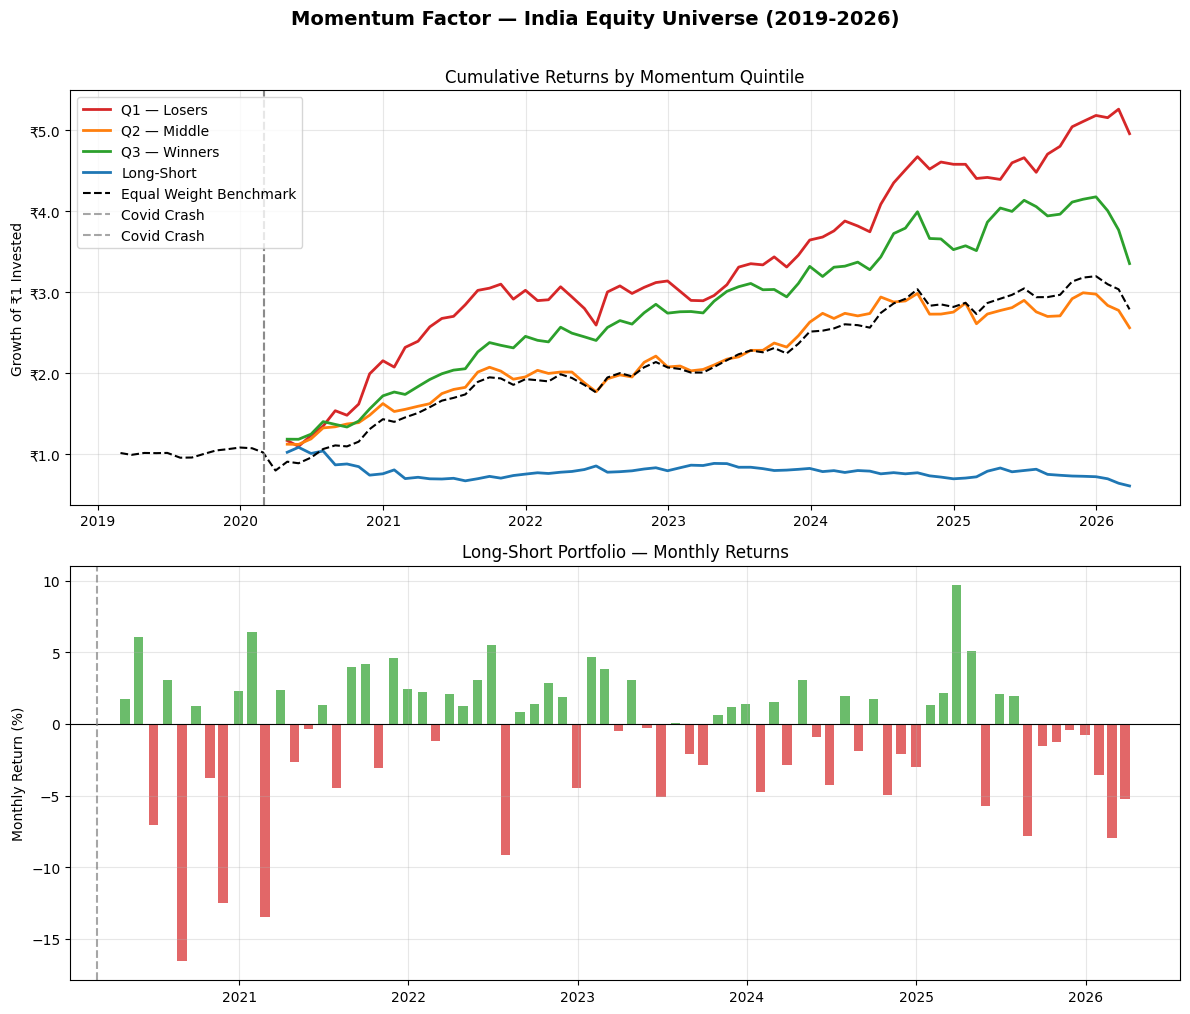

Chart saved to momentum_results.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Momentum Factor — India Equity Universe (2019-2026)', 
             fontsize=14, fontweight='bold', y=1.01)

# Chart 1 — Cumulative returns
ax1 = axes[0]
colors = {'Q1': '#d62728', 'Q2': '#ff7f0e', 'Q3': '#2ca02c', 'LS': '#1f77b4'}
labels = {'Q1': 'Q1 — Losers', 'Q2': 'Q2 — Middle', 
          'Q3': 'Q3 — Winners', 'LS': 'Long-Short'}

for col in ['Q1', 'Q2', 'Q3', 'LS']:
    cumulative = (1 + portfolios[col].dropna()).cumprod()
    ax1.plot(cumulative.index, cumulative.values, 
             label=labels[col], color=colors[col], linewidth=2)

# ← ADD BENCHMARK HERE, right after this loop
benchmark = monthly_returns.mean(axis=1)
benchmark_cum = (1 + benchmark).cumprod()
ax1.plot(benchmark_cum.index, benchmark_cum.values,
         label='Equal Weight Benchmark',
         color='black',
         linewidth=1.5,
         linestyle='--')

ax1.axvline(pd.Timestamp('2020-03-01'), color='grey', 
            linestyle='--', alpha=0.7, label='Covid Crash')

ax1.axvline(pd.Timestamp('2020-03-01'), color='grey', 
            linestyle='--', alpha=0.7, label='Covid Crash')
ax1.set_title('Cumulative Returns by Momentum Quintile', fontsize=12)
ax1.set_ylabel('Growth of ₹1 Invested')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:.1f}'))

# Chart 2 — Monthly LS returns
ax2 = axes[1]
ls_returns = portfolios['LS'].dropna()
colors_bar = ['#2ca02c' if x > 0 else '#d62728' for x in ls_returns]
ax2.bar(ls_returns.index, ls_returns.values * 100, 
        color=colors_bar, alpha=0.7, width=20)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.axvline(pd.Timestamp('2020-03-01'), color='grey', 
            linestyle='--', alpha=0.7)
ax2.set_title('Long-Short Portfolio — Monthly Returns', fontsize=12)
ax2.set_ylabel('Monthly Return (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('momentum_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to momentum_results.png")

In [10]:
# Check which stocks are in Q3 (should be low vol)
date = vol_scores.index[-2]  # second to last month
scores = vol_scores.loc[date].dropna()
quantile_labels = pd.qcut(scores, 3, labels=['Q3', 'Q2', 'Q1'])

print("Q3 stocks (should be LOW vol):")
print(scores[quantile_labels == 'Q3'].sort_values())

print("\nQ1 stocks (should be HIGH vol):")
print(scores[quantile_labels == 'Q1'].sort_values())

Q3 stocks (should be LOW vol):
HDFCBANK      0.041477
HINDUNILVR    0.043598
ICICIBANK     0.045426
JSWSTEEL      0.053000
AXISBANK      0.059332
ITC           0.059673
Name: 2026-02-27 00:00:00, dtype: float64

Q1 stocks (should be HIGH vol):
TITAN        0.066115
SUNPHARMA    0.067485
MARUTI       0.071393
INFY         0.074615
TATASTEEL    0.079807
HCLTECH      0.085877
Name: 2026-02-27 00:00:00, dtype: float64


In [11]:
portfolios.to_csv("vol_portfolios.csv")
print("Saved vol portfolios")

Saved vol portfolios
